In [1]:
import osmnx as ox
import shapely.geometry as geom
import networkx as  nx
from shapely.geometry import box
import os
import math

In [2]:
region_size = 0.001  # degrees
m = 5# number of grid cells in a region

In [3]:
bbox = (41.1406333 - region_size, -8.6886988 - region_size, 41.1858412 + region_size, -8.5559061 + region_size)

In [4]:
POI_TAG_MAP = {
    "healthcare": [("amenity", "hospital")],
    "education": [
        ("amenity", "school"),
        ("amenity", "college"),
        ("amenity", "university")
    ],
    "business": [("building", "commercial"),("building", "office")],
    "religious": [("building", "cathedral")],
    "commercial": [("shop", "mall")],
    "transport_hub": [
        ("building", "transportation"),
        ("amenity", "bus_station"),
    ],
    "event_venue": [("leisure", "stadium")],
}


In [5]:
region_x = math.floor((bbox[3] - bbox[1]) / region_size)
region_y = math.floor((bbox[2] - bbox[0]) / region_size)
region_id = (int(region_x), int(region_y))
print("Region ID:", region_id)

Region ID: (134, 47)


In [6]:
def build_overpass_query(bbox, poi_tag_map):
    """
    bbox = (min_lat, min_lon, max_lat, max_lon)
    """
    min_lat, min_lon, max_lat, max_lon = bbox
    query_parts = []

    for group, tags in poi_tag_map.items():
        for k, v in tags:
            query_parts.append(
                f'nwr["{k}"="{v}"]({min_lat},{min_lon},{max_lat},{max_lon});'
            )

    query = f"""
    [out:json][timeout:25];
    (
        {''.join(query_parts)}
    );
    out center;
    """
    return query
overpass_query = build_overpass_query(bbox, POI_TAG_MAP)
print(overpass_query)


    [out:json][timeout:25];
    (
        nwr["amenity"="hospital"](41.1396333,-8.689698799999999,41.186841199999996,-8.5549061);nwr["amenity"="school"](41.1396333,-8.689698799999999,41.186841199999996,-8.5549061);nwr["amenity"="college"](41.1396333,-8.689698799999999,41.186841199999996,-8.5549061);nwr["amenity"="university"](41.1396333,-8.689698799999999,41.186841199999996,-8.5549061);nwr["building"="commercial"](41.1396333,-8.689698799999999,41.186841199999996,-8.5549061);nwr["building"="office"](41.1396333,-8.689698799999999,41.186841199999996,-8.5549061);nwr["building"="cathedral"](41.1396333,-8.689698799999999,41.186841199999996,-8.5549061);nwr["shop"="mall"](41.1396333,-8.689698799999999,41.186841199999996,-8.5549061);nwr["building"="transportation"](41.1396333,-8.689698799999999,41.186841199999996,-8.5549061);nwr["amenity"="bus_station"](41.1396333,-8.689698799999999,41.186841199999996,-8.5549061);nwr["leisure"="stadium"](41.1396333,-8.689698799999999,41.186841199999996,-8.5549

In [7]:
import requests

OVERPASS_URL = "https://overpass-api.de/api/interpreter"

def fetch_pois(bbox, poi_tag_map):
    query = build_overpass_query(bbox, poi_tag_map)
    response = requests.post(OVERPASS_URL, data=query)
    response.raise_for_status()
    return response.json()["elements"]
osm_data = fetch_pois(bbox, POI_TAG_MAP)
print(f"Fetched {len(osm_data)} POIs from OSM.")

Fetched 612 POIs from OSM.


In [8]:
print(osm_data[:2])  # Print first 2 POI entries for inspection

[{'type': 'node', 'id': 1238407982, 'lat': 41.1844164, 'lon': -8.682567, 'tags': {'name': 'Centro Comercial Newark', 'shop': 'mall'}}, {'type': 'node', 'id': 1243160587, 'lat': 41.184463, 'lon': -8.6824351, 'tags': {'name': 'Centro Comercial Parque', 'shop': 'mall'}}]


In [9]:
def get_poi_group(tags, poi_tag_map):
    for group, kvs in poi_tag_map.items():
        for k, v in kvs:
            if tags.get(k) == v:
                return group
    return None


In [10]:
from collections import defaultdict

def group_pois_by_type(osm_elements, poi_tag_map):
    grouped = defaultdict(list)

    for el in osm_elements:
        tags = el.get("tags", {})
        poi_group = get_poi_group(tags, poi_tag_map)

        if poi_group is None:
            continue  # ignore non-relevant POIs
        
        # extract lat/lon robustly
        if "lat" in el and "lon" in el:
            lat, lon = el["lat"], el["lon"]
        elif "center" in el:
            lat, lon = el["center"]["lat"], el["center"]["lon"]
        else:
            continue

        grouped[poi_group].append({
            "id": el["id"],
            "lat": lat,
            "lon": lon,
            "raw_tags": tags
        })

    return grouped


In [11]:
grouped = group_pois_by_type(osm_data, POI_TAG_MAP)

In [12]:
for k, v in grouped.items():
    print(k, len(v))

commercial 36
transport_hub 10
education 263
business 269
healthcare 20
event_venue 13
religious 1


In [18]:
city_min_lat, city_min_lon, city_max_lat, city_max_lon = bbox

num_regions_lon = math.ceil((city_max_lon - city_min_lon) / region_size)
num_regions_lat = math.ceil((city_max_lat - city_min_lat) / region_size)


grids = {}

for lon in range(num_regions_lon):
    for lat in range(num_regions_lat):
        region_id = (lon, lat)
        region_min_lat = city_min_lat + lat * region_size
        region_min_lon = city_min_lon + lon * region_size

        grids[region_id] = {
            "cell_id": region_id,
            "bbox": {
                "min_lat": region_min_lat,
                "min_lon": region_min_lon,
                "max_lat": region_min_lat + region_size,
                "max_lon": region_min_lon + region_size
            },
            "pois" : []
        }


In [19]:
print(osm_data[52])

{'type': 'node', 'id': 11905255221, 'lat': 41.1719734, 'lon': -8.6687252, 'tags': {'addr:city': 'Porto', 'addr:housenumber': '85', 'addr:postcode': '4100-186', 'addr:street': 'Travessa de Costibela', 'amenity': 'school', 'contact:email': 'appacdm.porto@escolas.min-edu.pt', 'contact:fax': '+351 226197469', 'contact:phone': '+351 226197460', 'name': 'Associação Portuguesa de Pais e Amigos do Cidadão Deficiente Mental do Porto', 'operator:type': 'private', 'ref': '800014', 'ref:qzp': 'QZP.09', 'short_name': 'APPACDM do Porto'}}


In [20]:
for i,poi in enumerate(osm_data):
    if ("lat" not in poi or "lon" not in poi) and "center" not in poi:
        print(f"POI {i} missing lat/lon")
        print(poi["type"])
        print(poi['tags'])
        break

In [21]:
OSM_TO_NORM_TYPE = {}
for norm_type, pairs in POI_TAG_MAP.items():
    for k, v in pairs:
        OSM_TO_NORM_TYPE[(k, v)] = norm_type
        
def get_normed_type(tags):
    if not tags:
        return None

    for (k, v), norm_type in OSM_TO_NORM_TYPE.items():
        if tags.get(k) == v:
            return norm_type

    return None


In [22]:
for poi in osm_data:
    if "lat" in poi and "lon" in poi:
            lat, lon = poi["lat"], poi["lon"]
    elif "center" in poi:
        lat, lon = poi["center"]["lat"], poi["center"]["lon"]
    if not (city_min_lat <= lat <= city_max_lat and city_min_lon <= lon <= city_max_lon):
        continue 
    
    rx = int((lon - city_min_lon) // region_size)
    ry = int((lat - city_min_lat) // region_size)

    rx = min(rx, num_regions_lon - 1)
    ry = min(ry, num_regions_lat - 1)
    
    cell = grids[(rx, ry)]
    norm_type = get_normed_type(poi.get("tags", {}))
    cell["pois"].append({
        "poi_id": poi["id"],
        "type": norm_type,
        "tags": poi.get("tags", {}),
        "lat": lat,
        "lon": lon
    })
    

In [23]:
regions_json = {
    f"{rx}_{ry}": region
    for (rx, ry), region in grids.items()
}

In [24]:
print(type(grids))
print(len(grids))

<class 'dict'>
6480


In [25]:
os.makedirs("mydata/poi_cell", exist_ok=True)

In [26]:
import json 

with open(f"mydata/poi_cell/porto_pois_{region_size}_{m}.json", "w", encoding="utf-8") as f:
    json.dump(regions_json, f, indent=2, ensure_ascii=False)

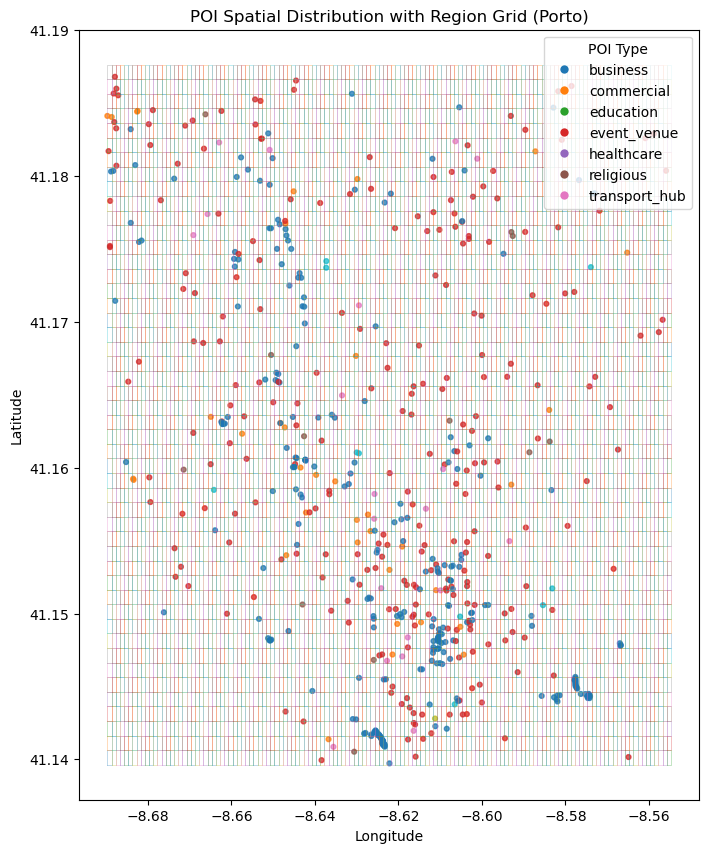

In [27]:
import json
import matplotlib.pyplot as plt
import matplotlib.cm as cm
# Load JSON
path = f"mydata/poi_cell/porto_pois_{region_size}_{m}.json"
with open(path, "r", encoding="utf-8") as f:
    grids = json.load(f)
# Collect POIs and region bounds
lats, lons, types = [], [], []
cell_bboxes = []
for cell in grids.values():
    cell_bboxes.append(cell["bbox"])
    for poi in cell.get("pois", []):
        lats.append(poi["lat"])
        lons.append(poi["lon"])
        types.append(poi["type"])

# Map POI types to integers
unique_types = sorted(set(types))
type_to_id = {t: i for i, t in enumerate(unique_types)}
type_ids = [type_to_id[t] for t in types]

# Plot POIs
plt.figure(figsize=(8, 10))
plt.scatter(lons, lats, c=type_ids,cmap="tab10", s=12, alpha=0.75)

# Plot region grid
for bbox in cell_bboxes:
    min_lat = bbox["min_lat"]
    max_lat = bbox["max_lat"]
    min_lon = bbox["min_lon"]
    max_lon = bbox["max_lon"]

    plt.plot(
        [min_lon, max_lon, max_lon, min_lon, min_lon],
        [min_lat, min_lat, max_lat, max_lat, min_lat],
        linewidth=0.5,
        alpha=0.4
    )

# Labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("POI Spatial Distribution with Region Grid (Porto)")

# Legend

cmap = plt.get_cmap("tab10")  # same colormap as scatter

handles = []
for poi_type, idx in type_to_id.items():
    handles.append(
        plt.Line2D(
            [0], [0],
            marker='o',
            linestyle='',
            markersize=6,
            markerfacecolor=cmap(idx),
            markeredgecolor='none',
            label=poi_type
        )
    )

plt.legend(handles=handles, title="POI Type", loc="upper right")

plt.show()